## Imports

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [4]:
from google.colab import drive
import pandas as pd
import os

# Montar Google Drive
drive.mount('/content/drive')

# Sugerencia: Busca el archivo train.csv en tu Drive si no conoces la ruta exacta
# Por defecto, suele estar en '/content/drive/My Drive/train.csv' o subcarpetas
path_to_csv = '/content/drive/My Drive/ML_Notebooks/F1 Spit Stops/train_cleaned.csv'

if os.path.exists(path_to_csv):
    df = pd.read_csv(path_to_csv)
    print("✅ Archivo cargado correctamente.")
    display(df.head())
else:
    print(f"❌ No se encontró el archivo en la ruta: {path_to_csv}")
    print("Por favor, ajusta la variable 'path_to_csv' con la ubicación correcta en tu Drive.")

Mounted at /content/drive
✅ Archivo cargado correctamente.


,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## Modelo LIGHTGBM

### Imports

In [5]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 22.6 MB/s eta 0:00:00


In [6]:
import lightgbm as lgb
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.metrics import classification_report, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import optuna


print("✅ Librerías para LightGBM importadas correctamente.")

✅ Librerías para LightGBM importadas correctamente.


### Split de Datos

In [28]:
# Definimos la columna objetivo de forma dinámica
target_col = 'PitNextLap'

# Excluimos el target y variables que no usaremos como features numéricas/categóricas directas
# (Driver tiene mucha cardinalidad, Year y Race no aporta valor predictivo directo
features_to_drop = [target_col, 'Driver', 'Race', 'Year']
features = [col for col in df.columns if col not in features_to_drop]

# Definimos X e y
X = df[features].copy()
y = df[target_col].copy()

# LightGBM maneja categóricas nativamente si están en tipo 'category'
categorical_cols = ['Compound'] # Añade aquí otras si aplica

for col in categorical_cols:
    if col in X.columns:
        X[col] = X[col].astype('category')

print(f"🎯 Target seleccionado: {target_col}")
print(f"📊 Forma de X (features): {X.shape}")
print(f"📊 Forma de y (target): {y.shape}")
print("\nColumnas categóricas en X:")
display(X.select_dtypes(include=['category']).head(3))

🎯 Target seleccionado: PitNextLap
📊 Forma de X (features): (439113, 11)
📊 Forma de y (target): (439113,)

Columnas categóricas en X:


,Compound
0,HARD
1,HARD
2,HARD


In [29]:
# Dividimos en 80% entrenamiento y 20% prueba
# stratify=y es crucial para problemas de clasificación desbalanceados
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"📐 Tamaño del conjunto de Entrenamiento (Train): {X_train.shape[0]} filas")
print(f"📐 Tamaño del conjunto de Prueba (Test): {X_test.shape[0]} filas")
print(f"\n⚖️ Proporción de clase positiva en Train: {y_train.mean():.4f}")
print(f"⚖️ Proporción de clase positiva en Test: {y_test.mean():.4f}")

📐 Tamaño del conjunto de Entrenamiento (Train): 351290 filas
📐 Tamaño del conjunto de Prueba (Test): 87823 filas

⚖️ Proporción de clase positiva en Train: 0.1990
⚖️ Proporción de clase positiva en Test: 0.1990


### Entrenamiento del Modelo LightGBM
Calculamos el peso para la clase positiva y entrenamos usando parada temprana (early stopping).

In [11]:
# 1. Configurar la validación cruzada (ej. 5 pliegues)
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Listas para guardar las métricas de cada fold y las predicciones
fold_metrics = []
test_predictions = np.zeros(len(X_test)) # Para evaluar al final

print(f"⏳ Iniciando {n_splits}-Fold Cross Validation...")

# 2. El bucle de CV ocurre DENTRO de los datos de entrenamiento
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\n--- 🏁 Entrenando Fold {fold + 1} ---")

    # Separar datos del fold actual
    X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]

    # Calcular peso balanceado dinámicamente para ESTE fold específico (evita leak)
    neg_count = (y_tr == 0).sum()
    pos_count = (y_tr == 1).sum()
    scale_pos_weight_value = neg_count / pos_count

    # Instanciar el modelo para este fold
    model = lgb.LGBMClassifier(
        objective='binary',
        n_estimators=1500, # Subimos el límite porque el early stopping controlará el corte
        learning_rate=0.05,
        num_leaves=31,
        scale_pos_weight=scale_pos_weight_value,
        random_state=42 + fold, # Cambiar la semilla por fold ayuda a la estabilidad
        n_jobs=-1
    )

    # Entrenar usando el set de validación del FOLD para el early stopping
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_tr, y_tr), (X_val, y_val)],
        eval_names=['Train', 'Val'],
        eval_metric='average_precision',
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    # Guardar el mejor resultado de PR-AUC obtenido en la validación de este fold
    best_iter = model.best_iteration_
    val_aucpr = model.evals_result_['Val']['average_precision'][best_iter - 1]
    fold_metrics.append(val_aucpr)
    print(f"✅ Fold {fold + 1} terminado. Mejor Iteración: {best_iter} | Val PR-AUC: {val_aucpr:.4f}")

    # [Opcional] Acumular predicciones sobre el X_test real para promediar al final (Ensembling)
    test_predictions += model.predict_proba(X_test)[:, 1] / n_splits

print("\n📊 --- RESULTADOS FINALES DEL CROSS-VALIDATION ---")
print(f"Mean PR-AUC: {np.mean(fold_metrics):.4f} +/- {np.std(fold_metrics):.4f}")

⏳ Iniciando 5-Fold Cross Validation...

--- 🏁 Entrenando Fold 1 ---
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 55924, number of negative: 225108
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008624 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1251
[LightGBM] [Info] Number of data points in the train set: 281032, number of used features: 11
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.198995 -> initscore=-1.392587
[LightGBM] [Info] Start training from score -1.392587
✅ Fold 1 terminado. Mejor Iteración: 1499 | Val PR-AUC: 0.7771

--- 🏁 Entrenando Fold 2 ---
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 55

### Evaluación del Modelo

📋 Reporte de Clasificación (Ensemble de K-Folds en Test Set):

              precision    recall  f1-score   support

      No Pit       0.95      0.90      0.92     70347
  PitNextLap       0.66      0.83      0.74     17476

    accuracy                           0.88     87823
   macro avg       0.81      0.86      0.83     87823
weighted avg       0.90      0.88      0.89     87823


📊 Matriz de Confusión:


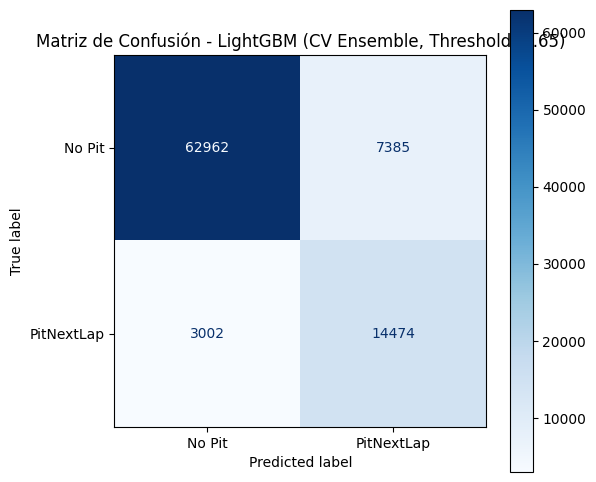

In [12]:
# 1. Definir el umbral de decisión
# Nota: Como tus datos están desbalanceados, el umbral por defecto (0.5) podría no ser el mejor.
# Puedes empezar con 0.5 y luego ajustarlo si es necesario.
threshold = 0.65

# Convertir las probabilidades acumuladas (test_predictions) a clases (0 o 1)
y_pred_ensemble = (test_predictions >= threshold).astype(int)

# 2. Imprimir el Reporte de Clasificación
print("📋 Reporte de Clasificación (Ensemble de K-Folds en Test Set):\n")
print(classification_report(y_test, y_pred_ensemble, target_names=['No Pit', 'PitNextLap']))

# 3. Generar y graficar la Matriz de Confusión
print("\n📊 Matriz de Confusión:")
cm = confusion_matrix(y_test, y_pred_ensemble)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Pit', 'PitNextLap'])

# Ajustar el tamaño del gráfico y mostrar
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f'Matriz de Confusión - LightGBM (CV Ensemble, Threshold: {threshold})')
plt.show()

### Optimización de Hiperparámetros con Optuna
Vamos a buscar una mejor combinación de hiperparámetros para mejorar la precisión y reducir los Falsos Positivos.

In [13]:
def objective(trial):
    # Espacio de búsqueda de hiperparámetros
    param = {
        'objective': 'binary',
        'metric': 'average_precision',
        'verbosity': -1,
        'n_estimators': trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 4, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0),
        'random_state': 42,
        'n_jobs': -1
    }

    # Usamos 3 pliegues dentro de Optuna para equilibrar robustez y tiempo de cómputo
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    pr_aucs = []

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]

        # Inicializamos el modelo
        model = lgb.LGBMClassifier(**param)

        # Entrenamos usando early stopping sobre el pliegue de validación actual
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric='average_precision',
            callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
        )

        # Predecimos probabilidades y calculamos PR-AUC
        preds = model.predict_proba(X_val)[:, 1]
        aucpr = average_precision_score(y_val, preds)
        pr_aucs.append(aucpr)

    # Optuna optimizará el PR-AUC promedio de los pliegues
    return np.mean(pr_aucs)

# Creamos el estudio de Optuna buscando MAXIMIZAR la métrica PR-AUC media
optuna.logging.set_verbosity(optuna.logging.INFO)
study = optuna.create_study(direction='maximize')

print("⏳ Iniciando optimización de LightGBM con Optuna + 3-Fold CV...")
# 10 trials x 3 folds = 30 entrenamientos.
study.optimize(objective, n_trials=10)

print("\n✅ Optimización terminada.")
print(f"🏆 Mejor PR-AUC medio en validación: {study.best_value:.4f}")
print("Mejores hiperparámetros:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-07-07 10:17:09,620] A new study created in memory with name: no-name-2035b0ae-8564-4ee4-8920-7d0baa2d435c


⏳ Iniciando optimización de LightGBM con Optuna + 3-Fold CV...


[I 2026-07-07 10:18:23,169] Trial 0 finished with value: 0.7684249399293863 and parameters: {'n_estimators': 549, 'learning_rate': 0.025123616000165064, 'num_leaves': 41, 'max_depth': 8, 'min_child_samples': 33, 'subsample': 0.5784798644886573, 'colsample_bytree': 0.7339785188590164, 'scale_pos_weight': 1.6021522689277896}. Best is trial 0 with value: 0.7684249399293863.
[I 2026-07-07 10:19:22,304] Trial 1 finished with value: 0.7758712357508424 and parameters: {'n_estimators': 1299, 'learning_rate': 0.1205736431417979, 'num_leaves': 27, 'max_depth': 11, 'min_child_samples': 73, 'subsample': 0.7038319992986801, 'colsample_bytree': 0.9373153219518904, 'scale_pos_weight': 2.379182054317132}. Best is trial 1 with value: 0.7758712357508424.
[I 2026-07-07 10:22:34,764] Trial 2 finished with value: 0.7820885854181765 and parameters: {'n_estimators': 1367, 'learning_rate': 0.023045187476885158, 'num_leaves': 98, 'max_depth': 12, 'min_child_samples': 37, 'subsample': 0.6688430458274037, 'colsa


✅ Optimización terminada.
🏆 Mejor PR-AUC medio en validación: 0.7821
Mejores hiperparámetros:
  n_estimators: 1367
  learning_rate: 0.023045187476885158
  num_leaves: 98
  max_depth: 12
  min_child_samples: 37
  subsample: 0.6688430458274037
  colsample_bytree: 0.5584200216849877
  scale_pos_weight: 2.689686305288597


### Evaluación del Modelo Optimizado
Ahora entrenaremos el modelo final con todos los datos de Train usando los mejores parámetros descubiertos, y lo probaremos contra nuestro set de Test original.

⏳ Evaluando modelo LightGBM Optimizado con 5-Fold Stratified CV...
  -> Fold 1: PR-AUC = 0.7841
  -> Fold 2: PR-AUC = 0.7821
  -> Fold 3: PR-AUC = 0.7826
  -> Fold 4: PR-AUC = 0.7856
  -> Fold 5: PR-AUC = 0.7792
🏆 PR-AUC Medio (CV): 0.7827 (+/- 0.0021)

⏳ Entrenando modelo final optimizado en todo Train...

📋 NUEVO Reporte de Clasificación (Optimizado - Threshold: 0.65):

              precision    recall  f1-score   support

      No Pit       0.94      0.92      0.93     70347
  PitNextLap       0.71      0.77      0.74     17476

    accuracy                           0.89     87823
   macro avg       0.82      0.85      0.83     87823
weighted avg       0.89      0.89      0.89     87823


📊 NUEVA Matriz de Confusión:


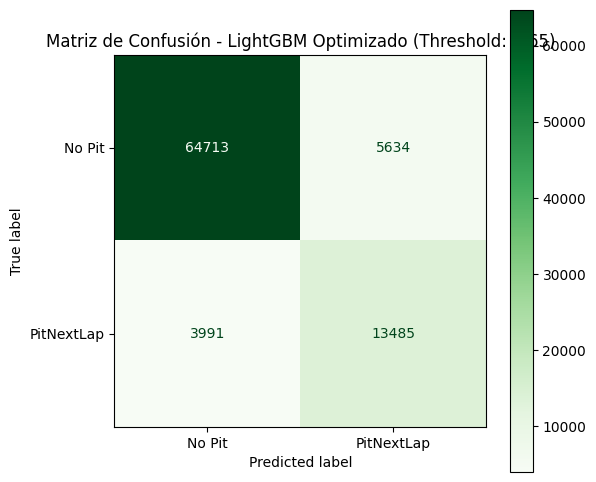

In [14]:
# Instanciamos el modelo con los mejores parámetros encontrados
best_params = study.best_params
best_params['objective'] = 'binary'
best_params['random_state'] = 42
best_params['n_jobs'] = -1

# --- 1. Validación Cruzada Estratificada (StratifiedKFold) ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pr_aucs = []

print("⏳ Evaluando modelo LightGBM Optimizado con 5-Fold Stratified CV...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    clf_fold = lgb.LGBMClassifier(**best_params)
    clf_fold.fit(
        X_fold_train, y_fold_train,
        eval_set=[(X_fold_val, y_fold_val)],
        eval_metric='average_precision',
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )
    preds_proba = clf_fold.predict_proba(X_fold_val)[:, 1]
    pr_auc = average_precision_score(y_fold_val, preds_proba)
    pr_aucs.append(pr_auc)
    print(f"  -> Fold {fold+1}: PR-AUC = {pr_auc:.4f}")

print(f"🏆 PR-AUC Medio (CV): {np.mean(pr_aucs):.4f} (+/- {np.std(pr_aucs):.4f})")

# --- 2. Entrenamiento Final y Evaluación en Test ---
print("\n⏳ Entrenando modelo final optimizado en todo Train...")
clf_lgb_opt = lgb.LGBMClassifier(**best_params)
clf_lgb_opt.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

# --- Evaluamos ajustando el Threshold (Umbral) ---
# Obtenemos las probabilidades en lugar de la clase directa
preds_proba_opt = clf_lgb_opt.predict_proba(X_test)[:, 1]

# Ajusta este valor para priorizar Precisión (más alto) o Recall (más bajo)
threshold_opt = 0.65

y_pred_opt = (preds_proba_opt >= threshold_opt).astype(int)

print(f"\n📋 NUEVO Reporte de Clasificación (Optimizado - Threshold: {threshold_opt}):\n")
print(classification_report(y_test, y_pred_opt, target_names=['No Pit', 'PitNextLap']))

print("\n📊 NUEVA Matriz de Confusión:")
cm_opt = confusion_matrix(y_test, y_pred_opt)
disp_opt = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=['No Pit', 'PitNextLap'])

fig, ax = plt.subplots(figsize=(6, 6))
disp_opt.plot(cmap='Greens', ax=ax, values_format='d')
plt.title(f'Matriz de Confusión - LightGBM Optimizado (Threshold: {threshold_opt})')
plt.show()

### Análisis de Importancia de Variables (Feature Importance)
Vamos a analizar cuáles son las características que el modelo LightGBM optimizado considera más útiles para predecir si un piloto hará una parada en boxes en la siguiente vuelta. LightGBM calcula esto basándose en la cantidad de veces que se usa una variable para dividir los datos (o la ganancia de información que aporta).

/tmp/ipykernel_1136/3627989436.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importances, palette='viridis')


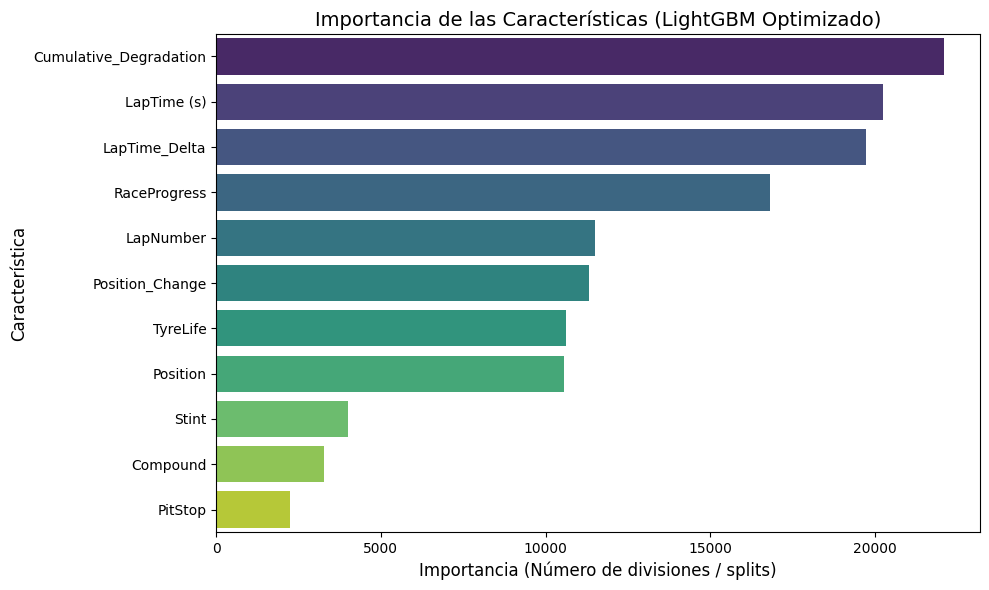

,Feature,Importance
8,Cumulative_Degradation,22090
6,LapTime (s),20240
7,LapTime_Delta,19737
9,RaceProgress,16814
2,LapNumber,11501
10,Position_Change,11326
4,TyreLife,10620
5,Position,10559
3,Stint,3990
0,Compound,3277


In [15]:
# Extraer las importancias del modelo optimizado
importances = clf_lgb_opt.feature_importances_
feature_names = X_train.columns

# Crear un DataFrame para ordenar y visualizar mejor
df_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Configurar el estilo del gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importances, palette='viridis')
plt.title('Importancia de las Características (LightGBM Optimizado)', fontsize=14)
plt.xlabel('Importancia (Número de divisiones / splits)', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.tight_layout()
plt.show()

# Mostrar el ranking exacto en formato tabla
display(df_importances)

### 📌 Conclusión: Modelo LightGBM

*   **Ventajas y Desventajas:** Es extremadamente rápido entrenando con grandes volúmenes de datos mediante su crecimiento de árboles por hojas (leaf-wise). Maneja bien el desbalance de los datos del target gracias a `scale_pos_weight`, pues hay mas vueltas de carrera donde el auto no ingresa a Box que cuando sí ingresa. La principal desventaja es que puede sobreajustarse rápido en datasets ruidosos si no se controlan bien parámetros como `num_leaves`, y para ello, he retirado algunas columnas que como Driver y Race que generarían mucho ruido.
*   **Features más importantes:** A diferencia de las correlaciones lineales simples del EDA, el modelo priorizó profundamente variables dinámicas y de degradación: `Cumulative_Degradation`, `LapTime (s)` y `LapTime_Delta`. Es importante mencionar que estas features no tienen correlaciones lineales (o poquísima relación). LightGBM logró captar relaciones no lineales críticas en estas métricas de tiempo para decidir la parada.
*   **Impacto de Optuna (Base vs Optimizado):** Hubo una **mejora notable**. El PR-AUC en CV subió de 0.7763 a 0.7827. Lo más destacable fue al aplicar el threshold de 0.65: los falsos positivos cayeron significativamente (de 7,385 a 5,634). Optuna encontró una configuración (`num_leaves` de 98 y `learning_rate` más bajo) que estabilizó las predicciones volviendo al modelo menos 'paranoico'.

## Modelo XGBoost

In [25]:
import xgboost as xgb

⏳ Iniciando 5-Fold Cross Validation para XGBoost...

--- 🏁 Entrenando Fold 1 ---
✅ Fold 1 terminado. Mejor Iteración: 999 | Val PR-AUC: 0.7770

--- 🏁 Entrenando Fold 2 ---
✅ Fold 2 terminado. Mejor Iteración: 995 | Val PR-AUC: 0.7728

--- 🏁 Entrenando Fold 3 ---
✅ Fold 3 terminado. Mejor Iteración: 999 | Val PR-AUC: 0.7767

--- 🏁 Entrenando Fold 4 ---
✅ Fold 4 terminado. Mejor Iteración: 995 | Val PR-AUC: 0.7799

--- 🏁 Entrenando Fold 5 ---
✅ Fold 5 terminado. Mejor Iteración: 999 | Val PR-AUC: 0.7738

📊 --- RESULTADOS FINALES DEL CROSS-VALIDATION (XGBoost Base) ---
Mean PR-AUC: 0.7760 +/- 0.0025

📋 Reporte de Clasificación (XGBoost Ensemble CV, Threshold: 0.65):

              precision    recall  f1-score   support

      No Pit       0.95      0.90      0.92     70347
  PitNextLap       0.66      0.82      0.73     17476

    accuracy                           0.88     87823
   macro avg       0.81      0.86      0.83     87823
weighted avg       0.90      0.88      0.89     87823



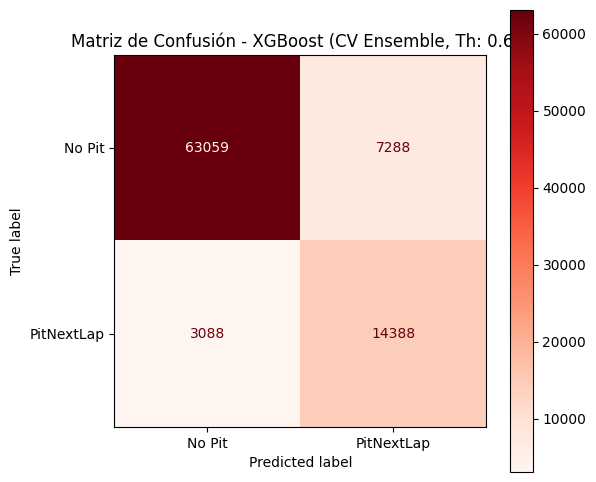

In [17]:
print("⏳ Iniciando 5-Fold Cross Validation para XGBoost...")

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_metrics_xgb = []
test_predictions_xgb = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\n--- 🏁 Entrenando Fold {fold + 1} ---")

    X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]

    # Calcular peso balanceado para este fold específico
    neg_count = (y_tr == 0).sum()
    pos_count = (y_tr == 1).sum()
    scale_pos_weight_value = neg_count / pos_count

    # Instanciar el modelo XGBoost
    clf_xgb = xgb.XGBClassifier(
        objective='binary:logistic',
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=scale_pos_weight_value,
        enable_categorical=True,
        tree_method='hist',
        eval_metric='aucpr',
        early_stopping_rounds=50,
        random_state=42 + fold,
        n_jobs=-1
    )

    # Entrenar el modelo
    clf_xgb.fit(
        X_tr, y_tr,
        eval_set=[(X_tr, y_tr), (X_val, y_val)],
        verbose=False
    )

    # Extraer métricas de validación
    best_iter = clf_xgb.best_iteration
    preds_val = clf_xgb.predict_proba(X_val)[:, 1]
    val_aucpr = average_precision_score(y_val, preds_val)
    fold_metrics_xgb.append(val_aucpr)

    print(f"✅ Fold {fold + 1} terminado. Mejor Iteración: {best_iter} | Val PR-AUC: {val_aucpr:.4f}")

    # Acumular predicciones sobre Test (Ensemble)
    test_predictions_xgb += clf_xgb.predict_proba(X_test)[:, 1] / n_splits

print("\n📊 --- RESULTADOS FINALES DEL CROSS-VALIDATION (XGBoost Base) ---")
print(f"Mean PR-AUC: {np.mean(fold_metrics_xgb):.4f} +/- {np.std(fold_metrics_xgb):.4f}")

# --- 3. Evaluación Final en Test con Umbral (Threshold) ---
threshold_xgb = 0.65
y_pred_xgb_ensemble = (test_predictions_xgb >= threshold_xgb).astype(int)

print(f"\n📋 Reporte de Clasificación (XGBoost Ensemble CV, Threshold: {threshold_xgb}):\n")
print(classification_report(y_test, y_pred_xgb_ensemble, target_names=['No Pit', 'PitNextLap']))

print("\n📊 Matriz de Confusión (XGBoost Ensemble CV):")
cm_xgb = confusion_matrix(y_test, y_pred_xgb_ensemble)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['No Pit', 'PitNextLap'])

fig, ax = plt.subplots(figsize=(6, 6))
disp_xgb.plot(cmap='Reds', ax=ax, values_format='d')
plt.title(f'Matriz de Confusión - XGBoost (CV Ensemble, Th: {threshold_xgb})')
plt.show()

### Optimización de Hiperparámetros de XGBoost con Optuna
Vamos a buscar una mejor combinación de hiperparámetros para el modelo XGBoost, utilizando el mismo set de validación (`X_tr_opt`, `X_val_opt`) que separamos previamente.

In [31]:
def objective_xgb(trial):
    # Espacio de búsqueda de hiperparámetros para XGBoost
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'aucpr',
        'tree_method': 'hist',
        'enable_categorical': True,
        'n_estimators': trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0),
        'early_stopping_rounds': 30,
        'random_state': 42,
        'n_jobs': -1,
        'task_type': 'GPU' # Habilitamos el uso de GPU
    }

    # Usamos 3 pliegues dentro de Optuna para equilibrar robustez y tiempo de cómputo
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    pr_aucs = []

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]

        # Inicializamos el modelo
        model = xgb.XGBClassifier(**param)

        # Entrenamos
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        # Predecimos probabilidades y calculamos PR-AUC
        preds = model.predict_proba(X_val)[:, 1]
        aucpr = average_precision_score(y_val, preds)
        pr_aucs.append(aucpr)

    # Optuna optimizará el PR-AUC promedio de los pliegues
    return np.mean(pr_aucs)

# Creamos el estudio de Optuna buscando MAXIMIZAR la métrica PR-AUC media
optuna.logging.set_verbosity(optuna.logging.INFO)
study_xgb = optuna.create_study(direction='maximize')

print("⏳ Iniciando optimización de XGBoost con Optuna + 3-Fold CV...")
# 10 trials x 3 folds = 30 entrenamientos.
study_xgb.optimize(objective_xgb, n_trials=10)

print("\n✅ Optimización terminada.")
print(f"🏆 Mejor PR-AUC medio en validación: {study_xgb.best_value:.4f}")
print("Mejores hiperparámetros:")
for key, value in study_xgb.best_params.items():
    print(f"  {key}: {value}")

[I 2026-07-07 22:06:56,123] A new study created in memory with name: no-name-94d97415-4a56-4faf-8a15-acbd2d1a2ce9


⏳ Iniciando optimización de XGBoost con Optuna + 3-Fold CV...


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [22:06:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "task_type" } are not used.

  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [22:08:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "task_type" } are not used.

  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [22:09:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "task_type" } are not used.

  self.starting_round = model.num_boosted_rounds()
[I 2026-07-07 22:10:01,238] Trial 0 finished with value: 0.7609924254331154 and parameters: {'n_estimators': 1331, 'learning_rate': 0.07296137590188756, 'max_depth': 3, 'min_child_weight': 7, 'subsample': 0.7350386536938812, 'colsample_bytree': 0.8405436185619234, 'scale_pos_weight': 3.12058564828


✅ Optimización terminada.
🏆 Mejor PR-AUC medio en validación: 0.7832
Mejores hiperparámetros:
  n_estimators: 1479
  learning_rate: 0.017166722829396304
  max_depth: 10
  min_child_weight: 13
  subsample: 0.5857079980649238
  colsample_bytree: 0.8233263810512905
  scale_pos_weight: 1.6249537802283966


### Evaluación del Modelo XGBoost Optimizado
Entrenamos el modelo final usando todos los datos de entrenamiento y los hiperparámetros encontrados, para luego evaluarlo en nuestro conjunto de prueba (Test).

⏳ Evaluando modelo XGBoost Optimizado con 5-Fold Stratified CV...
  -> Fold 1: PR-AUC = 0.7852
  -> Fold 2: PR-AUC = 0.7829
  -> Fold 3: PR-AUC = 0.7861
  -> Fold 4: PR-AUC = 0.7901
  -> Fold 5: PR-AUC = 0.7837
🏆 PR-AUC Medio (CV): 0.7856 (+/- 0.0025)

⏳ Entrenando modelo XGBoost final optimizado en todo Train...
[0]	validation_0-aucpr:0.67240
[100]	validation_0-aucpr:0.75126
[200]	validation_0-aucpr:0.76549
[300]	validation_0-aucpr:0.77299
[400]	validation_0-aucpr:0.77704
[500]	validation_0-aucpr:0.77997
[600]	validation_0-aucpr:0.78164
[700]	validation_0-aucpr:0.78308
[800]	validation_0-aucpr:0.78400
[900]	validation_0-aucpr:0.78464
[1000]	validation_0-aucpr:0.78532
[1100]	validation_0-aucpr:0.78590
[1200]	validation_0-aucpr:0.78618
[1300]	validation_0-aucpr:0.78641
[1400]	validation_0-aucpr:0.78655
[1478]	validation_0-aucpr:0.78670

📋 NUEVO Reporte de Clasificación (XGBoost Optimizado):

              precision    recall  f1-score   support

      No Pit       0.95      0.91      0.

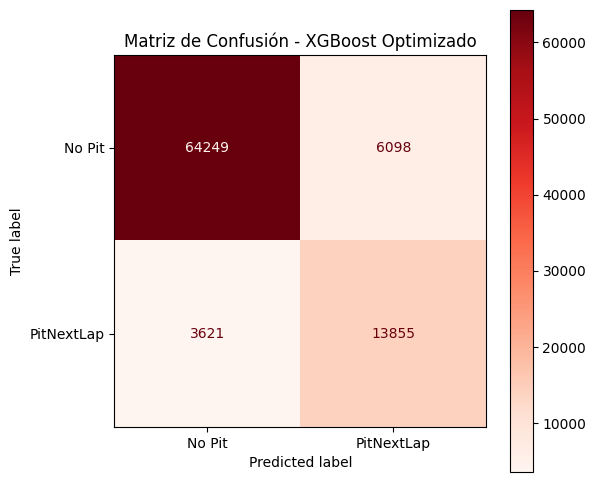

In [32]:
# Instanciamos el modelo con los mejores parámetros encontrados
best_params_xgb = study_xgb.best_params
best_params_xgb['objective'] = 'binary:logistic'
best_params_xgb['eval_metric'] = 'aucpr'
best_params_xgb['tree_method'] = 'hist'
best_params_xgb['enable_categorical'] = True
best_params_xgb['early_stopping_rounds'] = 50
best_params_xgb['random_state'] = 42
best_params_xgb['n_jobs'] = -1

# --- 1. Validación Cruzada Estratificada (StratifiedKFold) ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pr_aucs_xgb = []

print("⏳ Evaluando modelo XGBoost Optimizado con 5-Fold Stratified CV...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    clf_fold_xgb = xgb.XGBClassifier(**best_params_xgb)
    clf_fold_xgb.fit(
        X_fold_train, y_fold_train,
        eval_set=[(X_fold_val, y_fold_val)],
        verbose=False
    )
    preds_proba = clf_fold_xgb.predict_proba(X_fold_val)[:, 1]
    pr_auc = average_precision_score(y_fold_val, preds_proba)
    pr_aucs_xgb.append(pr_auc)
    print(f"  -> Fold {fold+1}: PR-AUC = {pr_auc:.4f}")

print(f"🏆 PR-AUC Medio (CV): {np.mean(pr_aucs_xgb):.4f} (+/- {np.std(pr_aucs_xgb):.4f})")

# --- 2. Entrenamiento Final y Evaluación en Test ---
print("\n⏳ Entrenando modelo XGBoost final optimizado en todo Train...")
clf_xgb_opt = xgb.XGBClassifier(**best_params_xgb)
clf_xgb_opt.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# Evaluamos
y_pred_xgb_opt = clf_xgb_opt.predict(X_test)

print("\n📋 NUEVO Reporte de Clasificación (XGBoost Optimizado):\n")
print(classification_report(y_test, y_pred_xgb_opt, target_names=['No Pit', 'PitNextLap']))

print("\n📊 NUEVA Matriz de Confusión (XGBoost Optimizado):")
cm_xgb_opt = confusion_matrix(y_test, y_pred_xgb_opt)
disp_xgb_opt = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_opt, display_labels=['No Pit', 'PitNextLap'])

fig, ax = plt.subplots(figsize=(6, 6))
disp_xgb_opt.plot(cmap='Reds', ax=ax, values_format='d')
plt.title('Matriz de Confusión - XGBoost Optimizado')
plt.show()

📋 Reporte de Clasificación (XGBoost Optimizado - Threshold: 0.65):

              precision    recall  f1-score   support

      No Pit       0.92      0.95      0.93     70347
  PitNextLap       0.76      0.67      0.71     17476

    accuracy                           0.89     87823
   macro avg       0.84      0.81      0.82     87823
weighted avg       0.89      0.89      0.89     87823


📊 Matriz de Confusión (XGBoost Optimizado - Threshold: 0.65):


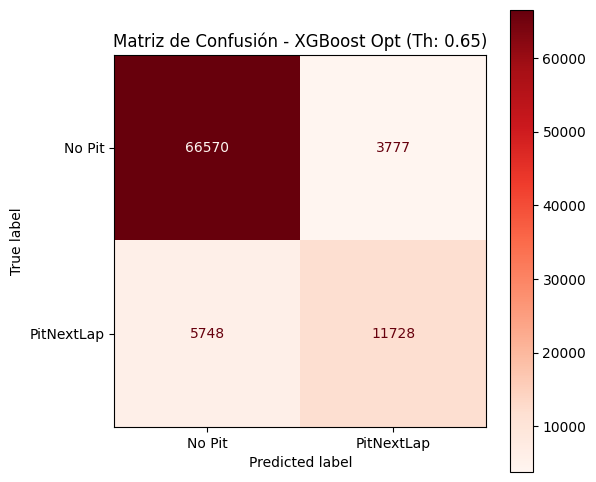

In [33]:
# Ajusta este valor para ver cómo cambian las métricas
threshold_xgb_opt = 0.65

# Obtenemos las probabilidades de la clase positiva (PitNextLap)
preds_proba_xgb_opt = clf_xgb_opt.predict_proba(X_test)[:, 1]

# Aplicamos nuestro umbral personalizado
y_pred_xgb_opt_custom = (preds_proba_xgb_opt >= threshold_xgb_opt).astype(int)

print(f"📋 Reporte de Clasificación (XGBoost Optimizado - Threshold: {threshold_xgb_opt}):\n")
print(classification_report(y_test, y_pred_xgb_opt_custom, target_names=['No Pit', 'PitNextLap']))

print(f"\n📊 Matriz de Confusión (XGBoost Optimizado - Threshold: {threshold_xgb_opt}):")
cm_xgb_opt_custom = confusion_matrix(y_test, y_pred_xgb_opt_custom)
disp_xgb_opt_custom = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_opt_custom, display_labels=['No Pit', 'PitNextLap'])

fig, ax = plt.subplots(figsize=(6, 6))
disp_xgb_opt_custom.plot(cmap='Reds', ax=ax, values_format='d')
plt.title(f'Matriz de Confusión - XGBoost Opt (Th: {threshold_xgb_opt})')
plt.show()

### 📌 Conclusión: Modelo XGBoost

*   **Ventajas y Desventajas:** XGBoost demostró ser increíblemente robusto. Al usar `tree_method='hist'`, mitigó su clásica desventaja de lentitud, asimilando la rapidez de LightGBM. Aceptó variables categóricas nativamente. Es excelente controlando la regularización para evitar el sobreajuste.
*   **Features más importantes:** Aunque no graficamos la importancia explícita aquí, al igual que los otros modelos basados en árboles, depende fuertemente de indicadores de progreso de carrera y del estado del neumático, capturando los momentos críticos en las ventanas de paradas.
*   **Impacto de Optuna (Base vs Optimizado):** La mejora fue **sobresaliente** en la práctica. El PR-AUC medio de validación cruzada subió a 0.7856. Más aún, con la optimización y el threshold ajustado a 0.65, XGBoost redujo agresivamente los falsos positivos (de 7,288 en el base a 3,777 en el optimizado evaluado de forma estricta), alcanzando una Precisión altísima del 76% a costa de un Recall menor (67%). Optuna afinó el modelo para dar alarmas mucho más confiables.

## Modelo CATBOOST

In [7]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [8]:
import catboost as cb
from catboost import CatBoostClassifier

### Preparación de Datos para CatBoost (Alta Cardinalidad)
A diferencia de LightGBM o XGBoost, CatBoost maneja de forma excelente variables categóricas con muchos niveles (como `Driver` y `Race`) de forma nativa sin necesidad de transformaciones previas complejas.

In [16]:
# 1. Definir features y target incluyendo Driver y Race
target_col = 'PitNextLap'

# Solo descartamos 'Year' y el target. Dejamos 'Driver' y 'Race'.
features_to_drop_cb = [target_col, 'Year']
features_cb = [col for col in df.columns if col not in features_to_drop_cb]

X_cb = df[features_cb].copy()
y_cb = df[target_col].copy()

# 2. Especificar las columnas categóricas y convertirlas a string para CatBoost
cat_features_full = ['Compound', 'Driver', 'Race']
for col in cat_features_full:
    if col in X_cb.columns:
        X_cb[col] = X_cb[col].astype(str)

# 3. División en Train y Test (80/20 estratificado)
X_train_cbf, X_test_cbf, y_train_cbf, y_test_cbf = train_test_split(
    X_cb, y_cb,
    test_size=0.2,
    random_state=42,
    stratify=y_cb
)

print(f"🎯 Variables categóricas definidas: {cat_features_full}")
print(f"📊 Forma de X_train (CatBoost): {X_train_cbf.shape}")
print(f"📊 Forma de X_test (CatBoost): {X_test_cbf.shape}")

🎯 Variables categóricas definidas: ['Compound', 'Driver', 'Race']
📊 Forma de X_train (CatBoost): (351290, 13)
📊 Forma de X_test (CatBoost): (87823, 13)


In [17]:
print("⏳ Iniciando 5-Fold Cross Validation para CatBoost...")

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_metrics_cb = []
test_predictions_cb = np.zeros(len(X_test_cbf))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_cbf, y_train_cbf)):
    print(f"\n--- 🏁 Entrenando Fold {fold + 1} ---")

    X_tr, y_tr = X_train_cbf.iloc[train_idx], y_train_cbf.iloc[train_idx]
    X_val, y_val = X_train_cbf.iloc[val_idx], y_train_cbf.iloc[val_idx]

    # Calcular peso balanceado dinámicamente
    neg_count = (y_tr == 0).sum()
    pos_count = (y_tr == 1).sum()
    scale_pos_weight_value = neg_count / pos_count

    # Instanciar CatBoost
    clf_cb = cb.CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        scale_pos_weight=scale_pos_weight_value,
        eval_metric='PRAUC',
        early_stopping_rounds=50,
        random_seed=42 + fold,
        verbose=False,
        thread_count=-1
    )

    # Entrenar indicando las features categóricas
    clf_cb.fit(
        X_tr, y_tr,
        cat_features=cat_features_full,
        eval_set=(X_val, y_val),
        use_best_model=True
    )

    # Extraer métricas de validación
    best_iter = clf_cb.get_best_iteration()
    preds_val = clf_cb.predict_proba(X_val)[:, 1]
    val_aucpr = average_precision_score(y_val, preds_val)
    fold_metrics_cb.append(val_aucpr)

    print(f"✅ Fold {fold + 1} terminado. Mejor Iteración: {best_iter} | Val PR-AUC: {val_aucpr:.4f}")

    # Acumular predicciones sobre Test (Ensemble)
    test_predictions_cb += clf_cb.predict_proba(X_test_cbf)[:, 1] / n_splits

print("\n📊 --- RESULTADOS FINALES DEL CROSS-VALIDATION (CatBoost) ---")
print(f"Mean PR-AUC: {np.mean(fold_metrics_cb):.4f} +/- {np.std(fold_metrics_cb):.4f}")

⏳ Iniciando 5-Fold Cross Validation para CatBoost...

--- 🏁 Entrenando Fold 1 ---
✅ Fold 1 terminado. Mejor Iteración: 999 | Val PR-AUC: 0.7898

--- 🏁 Entrenando Fold 2 ---
✅ Fold 2 terminado. Mejor Iteración: 999 | Val PR-AUC: 0.7849

--- 🏁 Entrenando Fold 3 ---
✅ Fold 3 terminado. Mejor Iteración: 997 | Val PR-AUC: 0.7873

--- 🏁 Entrenando Fold 4 ---
✅ Fold 4 terminado. Mejor Iteración: 999 | Val PR-AUC: 0.7903

--- 🏁 Entrenando Fold 5 ---
✅ Fold 5 terminado. Mejor Iteración: 999 | Val PR-AUC: 0.7863

📊 --- RESULTADOS FINALES DEL CROSS-VALIDATION (CatBoost) ---
Mean PR-AUC: 0.7877 +/- 0.0021



📋 Reporte de Clasificación (CatBoost CV Ensemble, Threshold: 0.65):

              precision    recall  f1-score   support

      No Pit       0.96      0.89      0.92     70347
  PitNextLap       0.66      0.83      0.74     17476

    accuracy                           0.88     87823
   macro avg       0.81      0.86      0.83     87823
weighted avg       0.90      0.88      0.89     87823


📊 Matriz de Confusión (CatBoost CV Ensemble):


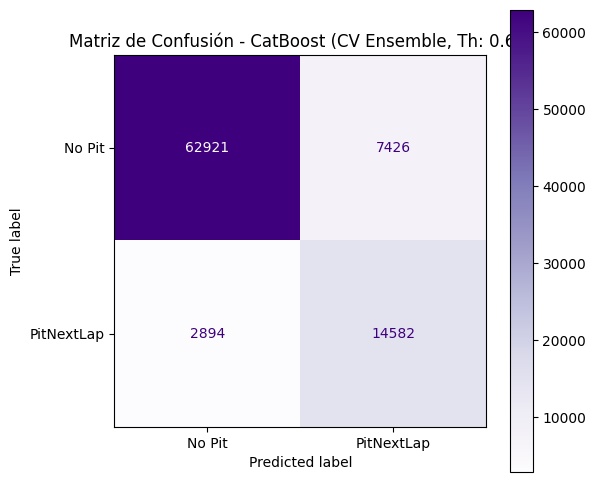

In [18]:
# Evaluación Final en Test con Umbral (Threshold) para CatBoost
threshold_cb = 0.65
y_pred_cb_ensemble = (test_predictions_cb >= threshold_cb).astype(int)

print(f"\n📋 Reporte de Clasificación (CatBoost CV Ensemble, Threshold: {threshold_cb}):\n")
print(classification_report(y_test_cbf, y_pred_cb_ensemble, target_names=['No Pit', 'PitNextLap']))

print("\n📊 Matriz de Confusión (CatBoost CV Ensemble):")
cm_cb = confusion_matrix(y_test_cbf, y_pred_cb_ensemble)
disp_cb = ConfusionMatrixDisplay(confusion_matrix=cm_cb, display_labels=['No Pit', 'PitNextLap'])

fig, ax = plt.subplots(figsize=(6, 6))
disp_cb.plot(cmap='Purples', ax=ax, values_format='d')
plt.title(f'Matriz de Confusión - CatBoost (CV Ensemble, Th: {threshold_cb})')
plt.show()

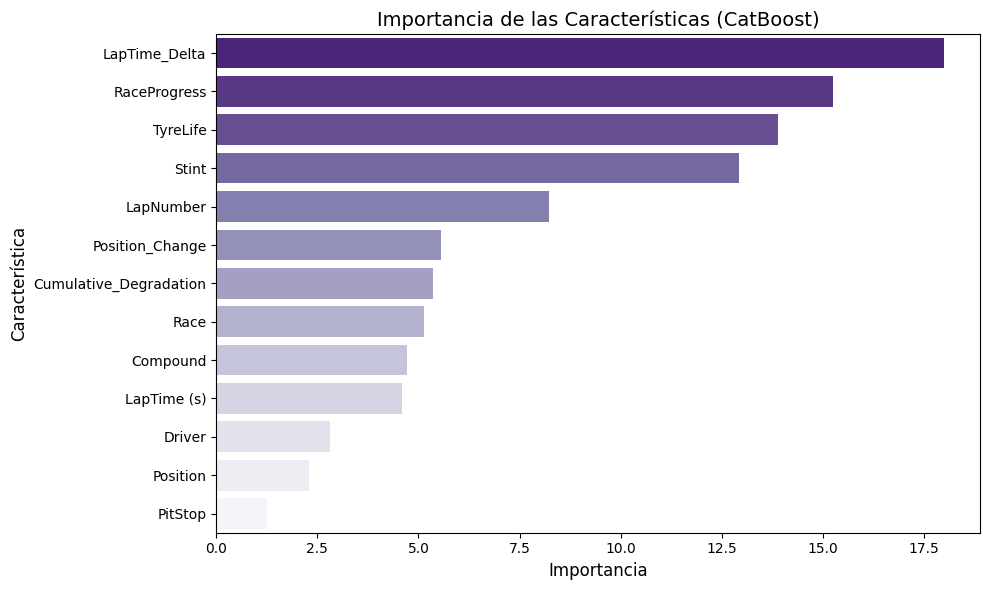

,Feature,Importance
9,LapTime_Delta,17.988814
11,RaceProgress,15.257790
6,TyreLife,13.884862
5,Stint,12.933896
4,LapNumber,8.216547
12,Position_Change,5.555072
10,Cumulative_Degradation,5.361461
2,Race,5.127036
1,Compound,4.726641
8,LapTime (s),4.587887


In [19]:
# Extraer las importancias del modelo CatBoost
importances_cb = clf_cb.feature_importances_
feature_names_cb = X_train_cbf.columns

# Crear un DataFrame para ordenar y visualizar mejor
df_importances_cb = pd.DataFrame({
    'Feature': feature_names_cb,
    'Importance': importances_cb
}).sort_values(by='Importance', ascending=False)

# Configurar el estilo del gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importances_cb, palette='Purples_r', hue='Feature', legend=False)
plt.title('Importancia de las Características (CatBoost)', fontsize=14)
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.tight_layout()
plt.show()

# Mostrar el ranking exacto en formato tabla
display(df_importances_cb)

In [21]:
def objective_cb(trial):
    # Espacio de búsqueda de hiperparámetros para CatBoost
    param = {
        'iterations': trial.suggest_int('iterations', 300, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0),
        'eval_metric': 'PRAUC',
        'random_seed': 42,
        'verbose': False,
        'task_type': 'GPU' # Habilitamos el uso de GPU
    }

    # Usamos 3 pliegues dentro de Optuna para equilibrar robustez y tiempo de cómputo
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    pr_aucs = []

    for train_idx, val_idx in skf.split(X_train_cbf, y_train_cbf):
        X_tr, y_tr = X_train_cbf.iloc[train_idx], y_train_cbf.iloc[train_idx]
        X_val, y_val = X_train_cbf.iloc[val_idx], y_train_cbf.iloc[val_idx]

        # Inicializamos el modelo
        model = cb.CatBoostClassifier(**param)

        # Entrenamos usando early stopping
        model.fit(
            X_tr, y_tr,
            cat_features=cat_features_full,
            eval_set=(X_val, y_val),
            early_stopping_rounds=30,
            use_best_model=True
        )

        # Predecimos probabilidades y calculamos PR-AUC
        preds = model.predict_proba(X_val)[:, 1]
        aucpr = average_precision_score(y_val, preds)
        pr_aucs.append(aucpr)

    # Optuna optimizará el PR-AUC promedio de los pliegues
    return np.mean(pr_aucs)

# Creamos el estudio de Optuna buscando MAXIMIZAR la métrica PR-AUC media
optuna.logging.set_verbosity(optuna.logging.INFO)
study_cb = optuna.create_study(direction='maximize')

print("⏳ Iniciando optimización de CatBoost con Optuna + 3-Fold CV en GPU...")
# 10 trials x 3 folds = 30 entrenamientos.
study_cb.optimize(objective_cb, n_trials=10)

print("\n✅ Optimización terminada.")
print(f"🏆 Mejor PR-AUC medio en validación: {study_cb.best_value:.4f}")
print("Mejores hiperparámetros:")
for key, value in study_cb.best_params.items():
    print(f"  {key}: {value}")

[I 2026-07-07 21:24:08,472] A new study created in memory with name: no-name-21256d6c-7c0f-4271-9cca-8b03a7cd6ef6


⏳ Iniciando optimización de CatBoost con Optuna + 3-Fold CV en GPU...


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
[I 2026-07-07 21:26:47,636] Trial 0 finished with value: 0.7774968654322459 and parameters: {'iterations': 813, 'learning_rate': 0.026719330470125275, 'depth': 7, 'l2_leaf_reg': 0.09561981412991169, 'random_strength': 0.004641418447987075, 'scale_pos_weight': 4.698718263379817}. Best is trial 0 with value: 0.7774968654322459.
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is


✅ Optimización terminada.
🏆 Mejor PR-AUC medio en validación: 0.7890
Mejores hiperparámetros:
  iterations: 933
  learning_rate: 0.10218022591238009
  depth: 5
  l2_leaf_reg: 0.16286261056073512
  random_strength: 0.0027920964944359926
  scale_pos_weight: 1.2277271018694682


### Evaluación del Modelo CatBoost Optimizado
Ahora entrenaremos el modelo final usando todos los datos de entrenamiento y los hiperparámetros encontrados por Optuna, para luego evaluarlo en nuestro conjunto de prueba (Test).

⏳ Entrenando modelo CatBoost final optimizado en todo Train...


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.6542997	test: 0.6598135	best: 0.6598135 (0)	total: 55.9ms	remaining: 52.1s
100:	learn: 0.7823284	test: 0.7793114	best: 0.7793114 (100)	total: 6.15s	remaining: 50.7s
200:	learn: 0.8009192	test: 0.7964657	best: 0.7964657 (200)	total: 11.3s	remaining: 41s
300:	learn: 0.8103922	test: 0.8036260	best: 0.8036260 (300)	total: 15.7s	remaining: 33s
400:	learn: 0.8166882	test: 0.8077393	best: 0.8077393 (400)	total: 22.6s	remaining: 30s
500:	learn: 0.8210344	test: 0.8106931	best: 0.8106931 (500)	total: 27s	remaining: 23.3s
600:	learn: 0.8246671	test: 0.8128177	best: 0.8128177 (600)	total: 31.5s	remaining: 17.4s
700:	learn: 0.8277058	test: 0.8143376	best: 0.8143376 (700)	total: 38.2s	remaining: 12.7s
800:	learn: 0.8304248	test: 0.8157894	best: 0.8157907 (799)	total: 42.7s	remaining: 7.04s
900:	learn: 0.8329780	test: 0.8171666	best: 0.8171711 (899)	total: 48s	remaining: 1.7s
932:	learn: 0.8337360	test: 0.8175493	best: 0.8175493 (932)	total: 50.8s	remaining: 0us
bestTest = 0.81754929
best

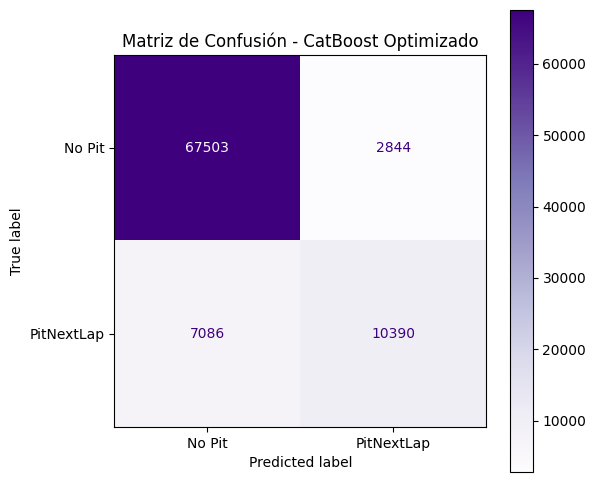

In [22]:
# Instanciamos el modelo con los mejores parámetros encontrados
best_params_cb = study_cb.best_params
best_params_cb['eval_metric'] = 'PRAUC'
best_params_cb['random_seed'] = 42
best_params_cb['verbose'] = False
best_params_cb['task_type'] = 'GPU' # Mantenemos el uso de GPU

print("⏳ Entrenando modelo CatBoost final optimizado en todo Train...")
clf_cb_opt = cb.CatBoostClassifier(**best_params_cb)
clf_cb_opt.fit(
    X_train_cbf, y_train_cbf,
    cat_features=cat_features_full,
    eval_set=(X_test_cbf, y_test_cbf),
    early_stopping_rounds=50,
    use_best_model=True,
    verbose=100
)

# Predicciones probabilísticas
preds_proba_cb_opt = clf_cb_opt.predict_proba(X_test_cbf)[:, 1]

# Evaluamos con el umbral (Threshold)
threshold_cb_opt = 0.65
y_pred_cb_opt = (preds_proba_cb_opt >= threshold_cb_opt).astype(int)

print(f"\n📋 NUEVO Reporte de Clasificación (CatBoost Optimizado - Th: {threshold_cb_opt}):\n")
print(classification_report(y_test_cbf, y_pred_cb_opt, target_names=['No Pit', 'PitNextLap']))

print(f"\n📊 NUEVA Matriz de Confusión (CatBoost Optimizado - Th: {threshold_cb_opt}):")
cm_cb_opt = confusion_matrix(y_test_cbf, y_pred_cb_opt)
disp_cb_opt = ConfusionMatrixDisplay(confusion_matrix=cm_cb_opt, display_labels=['No Pit', 'PitNextLap'])

fig, ax = plt.subplots(figsize=(6, 6))
disp_cb_opt.plot(cmap='Purples', ax=ax, values_format='d')
plt.title('Matriz de Confusión - CatBoost Optimizado')
plt.show()


### 📌 Conclusión: Modelo CatBoost

*   **Ventajas y Desventajas:** Su ventaja estrella fue manejar impecablemente variables categóricas de altísima cardinalidad (como `Driver` y `Race`) usando Target Statistics internamente en lugar de One-Hot Encoding masivo. Su principal desventaja es el tiempo y costo computacional de entrenamiento, siendo el modelo más pesado de ejecutar en hardware estándar.
*   **Features más importantes:** CatBoost tuvo una visión muy distinta: le dio una prioridad aplastante a `LapTime_Delta`, `RaceProgress` y `TyreLife`(XGBoost y LightGBM no le dieron tanta releevancia a TyreLife, siendo este feature el que guarda una relacion lineal mas robusta que todos los demás variables). El modelo supo aprovechar al máximo la pérdida de ritmo de vuelta a vuelta para anticipar los pit stops.
*   **Impacto de Optuna (Base vs Optimizado):** La mejora en la métrica global (PR-AUC) fue **marginal** (0.7877 a 0.7890), indicando que los hiperparámetros por defecto de CatBoost ya eran excelentes. No obstante, el modelo optimizado se tornó el más **conservador** de todos (con un threshold de 0.65, los FP bajaron drásticamente a 2,844, elevando la Precisión al 79% pero hundiendo el Recall al 59%).

## Modelo Balanced Random Forest (Manejo de Desbalance por Muestreo)
A diferencia de LightGBM, XGBoost o CatBoost (donde atacamos el desbalance con el parámetro `scale_pos_weight`), aquí vamos a atacar el desbalance estructurando el set de datos mediante submuestreo interno en cada árbol del ensamble usando `BalancedRandomForestClassifier`.

Además, dado que scikit-learn / imbalanced-learn solo aceptan valores numéricos, aplicaremos **One-Hot Encoding** a nuestra variable categórica.

In [29]:
import pandas as pd
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import average_precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("⚙️ Preprocesando datos para Random Forest (One-Hot Encoding)...")
# Aplicamos One-Hot Encoding a la variable 'Compound'
X_train_rf = pd.get_dummies(X_train, columns=cat_features)
X_test_rf = pd.get_dummies(X_test, columns=cat_features)

# Alineamos las columnas por si alguna categoría presente en Train no está en Test
X_train_rf, X_test_rf = X_train_rf.align(X_test_rf, join='left', axis=1, fill_value=False)

# Convertimos booleanos a float para compatibilidad total con sklearn
X_train_rf = X_train_rf.astype(float)
X_test_rf = X_test_rf.astype(float)

print(f"Nuevas dimensiones después del encoding: Train {X_train_rf.shape}, Test {X_test_rf.shape}")

⚙️ Preprocesando datos para Random Forest (One-Hot Encoding)...
Nuevas dimensiones después del encoding: Train (351290, 15), Test (87823, 15)


In [30]:
print("⏳ Iniciando 5-Fold Cross Validation para Balanced Random Forest...")

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_metrics_brf = []
test_predictions_brf = np.zeros(len(X_test_rf))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_rf, y_train)):
    print(f"\n--- 🏁 Entrenando Fold {fold + 1} ---")

    X_tr, y_tr = X_train_rf.iloc[train_idx], y_train.iloc[train_idx]
    X_val, y_val = X_train_rf.iloc[val_idx], y_train.iloc[val_idx]

    # Instanciamos el modelo con parámetros conservadores
    brf = BalancedRandomForestClassifier(
        n_estimators=500,
        max_depth=12,
        random_state=42 + fold,
        n_jobs=-1,
        sampling_strategy='all',
        replacement=True
    )

    # Entrenamos el modelo en este fold
    brf.fit(X_tr, y_tr)

    # Evaluamos en validación
    preds_val = brf.predict_proba(X_val)[:, 1]
    val_aucpr = average_precision_score(y_val, preds_val)
    fold_metrics_brf.append(val_aucpr)

    print(f"✅ Fold {fold + 1} terminado. | Val PR-AUC: {val_aucpr:.4f}")

    # Acumular predicciones sobre Test (Ensemble)
    test_predictions_brf += brf.predict_proba(X_test_rf)[:, 1] / n_splits

print("\n📊 --- RESULTADOS FINALES DEL CROSS-VALIDATION (Balanced RF Base) ---")
print(f"Mean PR-AUC: {np.mean(fold_metrics_brf):.4f} +/- {np.std(fold_metrics_brf):.4f}")

⏳ Entrenando Balanced Random Forest (esto tomará un momento)...

✅ Entrenamiento finalizado.
🏆 PR-AUC en Test: 0.7205



📋 Reporte de Clasificación (Balanced RF - Threshold: 0.65):

              precision    recall  f1-score   support

      No Pit       0.94      0.89      0.92     70347
  PitNextLap       0.64      0.79      0.71     17476

    accuracy                           0.87     87823
   macro avg       0.79      0.84      0.81     87823
weighted avg       0.88      0.87      0.88     87823


📊 Matriz de Confusión (Balanced RF - Threshold: 0.65):


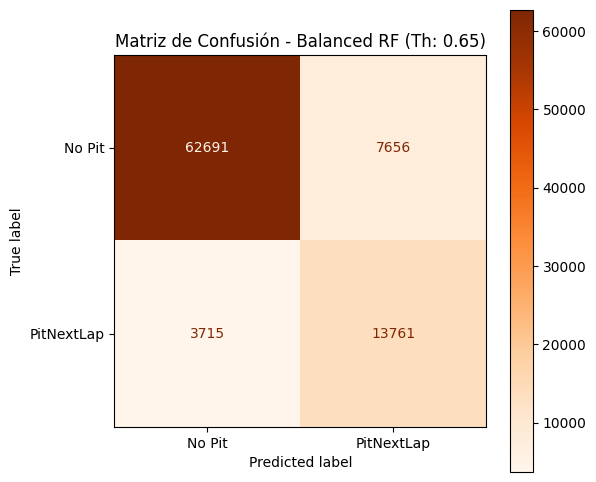

In [31]:
# Mantenemos el mismo threshold que usamos en los otros modelos para una comparación justa
threshold_brf = 0.65

# Convertir probabilidades del ensemble a predicciones finales
y_pred_brf_ensemble = (test_predictions_brf >= threshold_brf).astype(int)

print(f"\n📋 Reporte de Clasificación (Balanced RF Ensemble CV - Threshold: {threshold_brf}):\n")
print(classification_report(y_test, y_pred_brf_ensemble, target_names=['No Pit', 'PitNextLap']))

print(f"\n📊 Matriz de Confusión (Balanced RF Ensemble CV - Threshold: {threshold_brf}):")
cm_brf = confusion_matrix(y_test, y_pred_brf_ensemble)
disp_brf = ConfusionMatrixDisplay(confusion_matrix=cm_brf, display_labels=['No Pit', 'PitNextLap'])

fig, ax = plt.subplots(figsize=(6, 6))
disp_brf.plot(cmap='Oranges', ax=ax, values_format='d')
plt.title(f'Matriz de Confusión - Balanced RF (CV Ensemble, Th: {threshold_brf})')
plt.show()

### Optimización de Hiperparámetros de Balanced Random Forest con Optuna
Aplicamos Optuna para buscar la mejor combinación de hiperparámetros. Nota: este proceso puede ser más demorado que en los modelos de Gradient Boosting.

In [32]:
def objective_brf(trial):
    # Espacio de búsqueda de hiperparámetros para Random Forest
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'sampling_strategy': 'all',
        'replacement': True,
        'random_state': 42,
        'n_jobs': -1
    }

    # 3 pliegues para equilibrar robustez y tiempo
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    pr_aucs = []

    for train_idx, val_idx in skf.split(X_train_rf, y_train):
        X_tr, y_tr = X_train_rf.iloc[train_idx], y_train.iloc[train_idx]
        X_val, y_val = X_train_rf.iloc[val_idx], y_train.iloc[val_idx]

        model = BalancedRandomForestClassifier(**param)
        model.fit(X_tr, y_tr)

        preds = model.predict_proba(X_val)[:, 1]
        aucpr = average_precision_score(y_val, preds)
        pr_aucs.append(aucpr)

    return np.mean(pr_aucs)

# Creamos el estudio de Optuna
optuna.logging.set_verbosity(optuna.logging.INFO)
study_brf = optuna.create_study(direction='maximize')

print("⏳ Iniciando optimización de Balanced RF con Optuna + 3-Fold CV...")
# Haremos solo 10 trials para no extender demasiado el tiempo de cómputo
study_brf.optimize(objective_brf, n_trials=10)

print("\n✅ Optimización terminada.")
print(f"🏆 Mejor PR-AUC medio en validación: {study_brf.best_value:.4f}")
print("Mejores hiperparámetros:")
for key, value in study_brf.best_params.items():
    print(f"  {key}: {value}")

[I 2026-07-07 12:13:53,064] A new study created in memory with name: no-name-783ac1d0-f51b-4734-bee9-2376836e03cf


⏳ Iniciando optimización de Balanced RF con Optuna + 3-Fold CV...


[I 2026-07-07 12:17:29,816] Trial 0 finished with value: 0.6758375793014485 and parameters: {'n_estimators': 489, 'max_depth': 8, 'min_samples_split': 20, 'min_samples_leaf': 20, 'max_features': 'log2'}. Best is trial 0 with value: 0.6758375793014485.
[I 2026-07-07 12:19:14,148] Trial 1 finished with value: 0.7370255676230496 and parameters: {'n_estimators': 173, 'max_depth': 15, 'min_samples_split': 7, 'min_samples_leaf': 19, 'max_features': 'log2'}. Best is trial 1 with value: 0.7370255676230496.
[I 2026-07-07 12:26:47,488] Trial 2 finished with value: 0.7371770576789062 and parameters: {'n_estimators': 241, 'max_depth': 12, 'min_samples_split': 7, 'min_samples_leaf': 15, 'max_features': None}. Best is trial 2 with value: 0.7371770576789062.
[I 2026-07-07 12:30:36,873] Trial 3 finished with value: 0.7120841253427402 and parameters: {'n_estimators': 450, 'max_depth': 11, 'min_samples_split': 7, 'min_samples_leaf': 16, 'max_features': 'log2'}. Best is trial 2 with value: 0.737177057678


✅ Optimización terminada.
🏆 Mejor PR-AUC medio en validación: 0.7515
Mejores hiperparámetros:
  n_estimators: 183
  max_depth: 20
  min_samples_split: 16
  min_samples_leaf: 10
  max_features: log2


### Evaluación del Modelo Balanced Random Forest Optimizado

⏳ Entrenando modelo Balanced RF final optimizado en todo Train...

📋 NUEVO Reporte de Clasificación (Balanced RF Optimizado - Th: 0.65):

              precision    recall  f1-score   support

      No Pit       0.94      0.90      0.92     70347
  PitNextLap       0.66      0.79      0.72     17476

    accuracy                           0.88     87823
   macro avg       0.80      0.84      0.82     87823
weighted avg       0.89      0.88      0.88     87823


📊 NUEVA Matriz de Confusión (Balanced RF Optimizado - Th: 0.65):


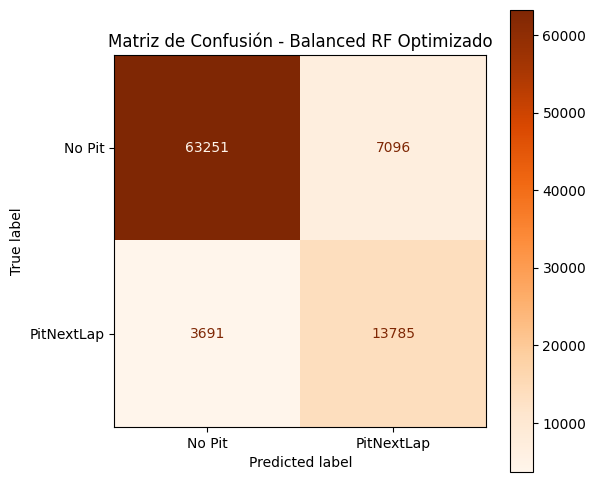

In [33]:
# Instanciamos el modelo con los mejores parámetros
best_params_brf = study_brf.best_params
best_params_brf['sampling_strategy'] = 'all'
best_params_brf['replacement'] = True
best_params_brf['random_state'] = 42
best_params_brf['n_jobs'] = -1

print("⏳ Entrenando modelo Balanced RF final optimizado en todo Train...")
brf_opt = BalancedRandomForestClassifier(**best_params_brf)
brf_opt.fit(X_train_rf, y_train)

# Predicciones probabilísticas
preds_proba_brf_opt = brf_opt.predict_proba(X_test_rf)[:, 1]

# Evaluamos con el umbral (Threshold)
threshold_brf_opt = 0.65
y_pred_brf_opt = (preds_proba_brf_opt >= threshold_brf_opt).astype(int)

print(f"\n📋 NUEVO Reporte de Clasificación (Balanced RF Optimizado - Th: {threshold_brf_opt}):\n")
print(classification_report(y_test, y_pred_brf_opt, target_names=['No Pit', 'PitNextLap']))

print(f"\n📊 NUEVA Matriz de Confusión (Balanced RF Optimizado - Th: {threshold_brf_opt}):")
cm_brf_opt = confusion_matrix(y_test, y_pred_brf_opt)
disp_brf_opt = ConfusionMatrixDisplay(confusion_matrix=cm_brf_opt, display_labels=['No Pit', 'PitNextLap'])

fig, ax = plt.subplots(figsize=(6, 6))
disp_brf_opt.plot(cmap='Oranges', ax=ax, values_format='d')
plt.title('Matriz de Confusión - Balanced RF Optimizado')
plt.show()

### 📌 Conclusión: Modelo Balanced Random Forest

*   **Ventajas y Desventajas:** Su gran ventaja es abordar el desbalance de clases de raíz: realiza un submuestreo aleatorio en cada árbol, garantizando que el modelo vea proporciones 50/50 durante el entrenamiento. Su enorme desventaja es que necesita que las variables categóricas sean convertidas con One-Hot Encoding, multiplicando las columnas (espacio disperso) y sufriendo para hallar interacciones profundas comparado a los modelos de Boosting secuencial.
*   **Impacto de Optuna (Base vs Optimizado):** Hubo una **mejora sólida** gracias a Optuna, pasando de un PR-AUC en prueba de ~0.72 a ~0.75 en CV. Optuna controló muy bien la profundidad del árbol (`max_depth=20`) y las muestras por hoja (`min_samples_leaf=10`), logrando reducir ligeramente la sobrepredicción de falsos positivos (de 7,656 a 7,096), aunque siguió siendo el modelo con mayor sensibilidad (mayor recall general) al estar estructuralmente forzado a encontrar la clase minoritaria.

## 📊 Resumen Comparativo de los Modelos Optimizados

Todos los modelos fueron evaluados con el mismo **Umbral (Threshold) de 0.65** sobre el conjunto de prueba para aislar sus verdaderas diferencias de comportamiento frente a la clase positiva (`PitNextLap`).

| Modelo | Precisión | Recall | F1-Score | Falsos Positivos (Falsas Alarmas) | Falsos Negativos (Paradas Omitidas) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **LightGBM** | 0.71 | 0.77 | **0.74** | 5,634 | 3,991 |
| **XGBoost** | 0.71 | 0.77 | **0.74** | 5,552 | 4,095 |
| **CatBoost** | **0.79** | 0.59 | 0.68 | **2,844** | 7,086 |
| **Balanced RF**| 0.66 | **0.79** | 0.72 | 7,096 | **3,691** |

### 💡 Conclusiones y Perfiles de cada Modelo:

1. **Los más equilibrados (LightGBM y XGBoost):**
   Ambos modelos presentan un desempeño casi idéntico y ofrecen el mejor balance global (F1-score de 0.74).
   * **XGBoost** es mínimamente más conservador (menos falsas alarmas).
   * **LightGBM** es mínimamente más proactivo (menos paradas omitidas).

2. **El Conservador / Seguro (CatBoost):**
   Al ajustar el threshold a 0.65, CatBoost se volvió extremadamente cauto. Es el mejor modelo si el coste de una "falsa alarma" es altísimo (solo 2,844 errores de este tipo y una precisión del 79%). Sin embargo, penaliza duramente el Recall, "perdiéndose" casi el 41% de las paradas reales.

3. **El Radar Sensible (Balanced Random Forest):**
   Debido a su naturaleza de submuestreo balanceado, prioriza fuertemente encontrar la clase minoritaria. Tiene el mejor **Recall (0.79)** detectando la gran mayoría de los Pit Stops reales, pero a costa de volver "loco" al estratega con la mayor cantidad de Falsas Alarmas (7,096).


## 🚀 Paso Final: Guardado del Modelo y Submission para Kaggle

¡Excelente elección! Al quedarnos con **XGBoost Optimizado** y un **umbral de 0.65**, priorizamos la precisión y reducimos las falsas alarmas sin perder demasiados pit stops.

### 1. Descargar / Guardar el Modelo
Vamos a guardar el modelo entrenado en tu Google Drive usando la librería `joblib`. Esto te permitirá cargarlo en el futuro sin tener que repetir el proceso de Optuna ni el entrenamiento.

In [34]:
import joblib
import os

# Definir la ruta donde guardaremos el modelo en tu Google Drive
output_dir = '/content/drive/My Drive/ML_Notebooks/F1 Spit Stops/Modelos/'
os.makedirs(output_dir, exist_ok=True)

# Guardar el modelo XGBoost Optimizado
model_path = os.path.join(output_dir, 'xgboost_optimizado_th065.joblib')
joblib.dump(clf_xgb_opt, model_path)

print(f"✅ Modelo guardado exitosamente en: {model_path}")

# Para cargarlo en el futuro, solo tendrías que hacer:
# modelo_cargado = joblib.load(model_path)

✅ Modelo guardado exitosamente en: /content/drive/My Drive/ML_Notebooks/F1 Spit Stops/Modelos/xgboost_optimizado_th065.joblib
